In [3]:
df = pd.read_csv('Reviews.csv')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\TAKI-
[nltk_data]     KUN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\TAKI-
[nltk_data]     KUN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\TAKI-
[nltk_data]     KUN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [5]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [7]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [6]:
df = df.dropna()

In [7]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df = df[df['HelpfulnessNumerator'] <= df['HelpfulnessDenominator']]
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


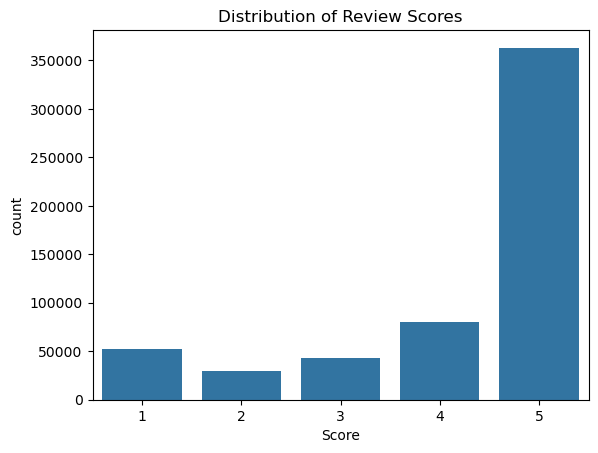

In [12]:
sns.countplot(x="Score", data=df)
plt.title("Distribution of Review Scores")
plt.show()

# five star reviews dominate

In [13]:
def sentiment(score):

    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(sentiment)
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive
...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive


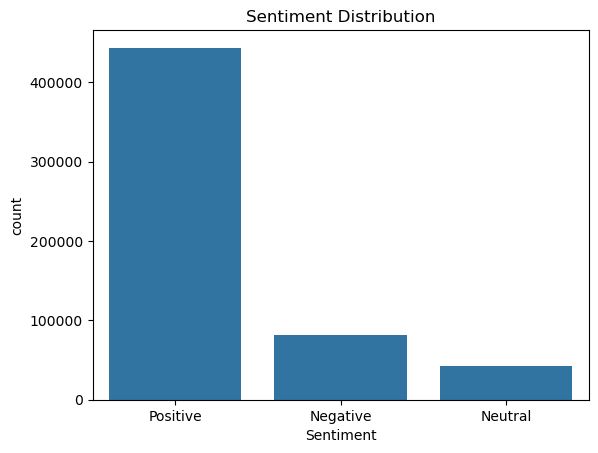

In [14]:
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

In [15]:
df["review"] = df["Summary"] + " " + df["Text"]
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,Good Quality Dog Food I have bought several of...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,Not as Advertised Product arrived labeled as J...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,"""Delight"" says it all This is a confection tha..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,Cough Medicine If you are looking for the secr...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,Great taffy Great taffy at a great price. The...
...,...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive,Will not do without Great for sesame chicken.....
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative,disappointed I'm disappointed with the flavor....
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive,Perfect for our maltipoo These stars are small...
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive,Favorite Training and reward treat These are t...


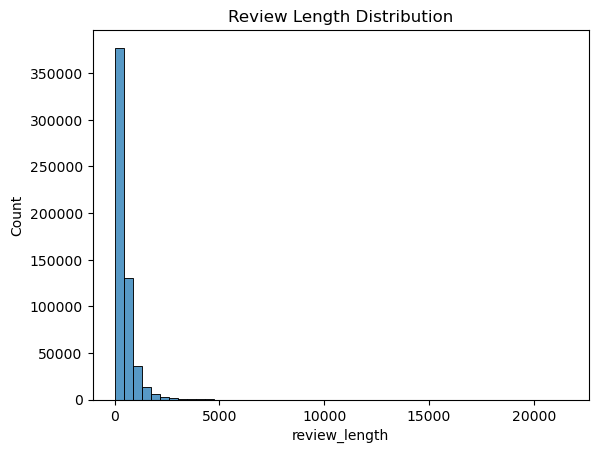

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,Good Quality Dog Food I have bought several of...,285
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,Not as Advertised Product arrived labeled as J...,208
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,"""Delight"" says it all This is a confection tha...",531
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,Cough Medicine If you are looking for the secr...,234
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,Great taffy Great taffy at a great price. The...,152
...,...,...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive,Will not do without Great for sesame chicken.....,169
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative,disappointed I'm disappointed with the flavor....,265
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive,Perfect for our maltipoo These stars are small...,397
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive,Favorite Training and reward treat These are t...,235


In [16]:
df["review_length"] = df["review"].apply(len)

sns.histplot(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.show()
df

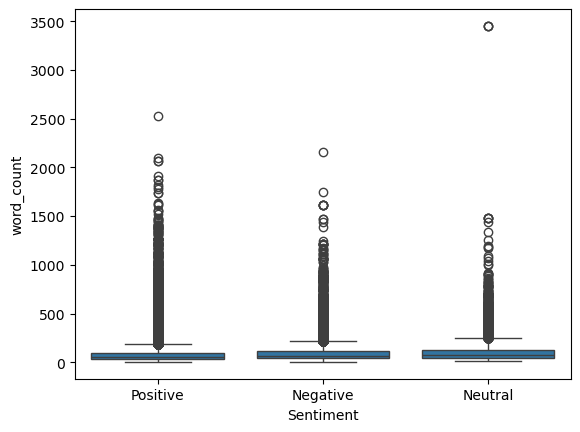

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,Good Quality Dog Food I have bought several of...,285,52
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,Not as Advertised Product arrived labeled as J...,208,34
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,"""Delight"" says it all This is a confection tha...",531,98
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,Cough Medicine If you are looking for the secr...,234,43
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,Great taffy Great taffy at a great price. The...,152,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive,Will not do without Great for sesame chicken.....,169,30
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative,disappointed I'm disappointed with the flavor....,265,47
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive,Perfect for our maltipoo These stars are small...,397,70
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive,Favorite Training and reward treat These are t...,235,40


In [17]:
df["word_count"] = df["review"].apply(lambda x: len(str(x).split()))
sns.boxplot(x="Sentiment", y="word_count", data=df)
plt.show()
df

In [18]:
# Text PreProcessing
def remove_html(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

df["clean_text"] = df["review"].apply(remove_html)

In [19]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,Good Quality Dog Food I have bought several of...,285,52,Good Quality Dog Food I have bought several of...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,Not as Advertised Product arrived labeled as J...,208,34,Not as Advertised Product arrived labeled as J...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,"""Delight"" says it all This is a confection tha...",531,98,"""Delight"" says it all This is a confection tha..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,Cough Medicine If you are looking for the secr...,234,43,Cough Medicine If you are looking for the secr...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,Great taffy Great taffy at a great price. The...,152,29,Great taffy Great taffy at a great price. The...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive,Will not do without Great for sesame chicken.....,169,30,Will not do without Great for sesame chicken.....
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative,disappointed I'm disappointed with the flavor....,265,47,disappointed I'm disappointed with the flavor....
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive,Perfect for our maltipoo These stars are small...,397,70,Perfect for our maltipoo These stars are small...
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive,Favorite Training and reward treat These are t...,235,40,Favorite Training and reward treat These are t...


In [20]:
def remove_punctuation(text):
    return re.sub('[^a-zA-Z]', ' ', text)

df["clean_text"] = df["clean_text"].apply(remove_punctuation)
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,Good Quality Dog Food I have bought several of...,285,52,Good Quality Dog Food I have bought several of...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,Not as Advertised Product arrived labeled as J...,208,34,Not as Advertised Product arrived labeled as J...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,"""Delight"" says it all This is a confection tha...",531,98,Delight says it all This is a confection tha...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,Cough Medicine If you are looking for the secr...,234,43,Cough Medicine If you are looking for the secr...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,Great taffy Great taffy at a great price. The...,152,29,Great taffy Great taffy at a great price The...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive,Will not do without Great for sesame chicken.....,169,30,Will not do without Great for sesame chicken ...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative,disappointed I'm disappointed with the flavor....,265,47,disappointed I m disappointed with the flavor ...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive,Perfect for our maltipoo These stars are small...,397,70,Perfect for our maltipoo These stars are small...
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive,Favorite Training and reward treat These are t...,235,40,Favorite Training and reward treat These are t...


In [22]:
#covert to lower case
df["clean_text"] = df["clean_text"].str.lower()
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,Good Quality Dog Food I have bought several of...,285,52,good quality dog food i have bought several of...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,Not as Advertised Product arrived labeled as J...,208,34,not as advertised product arrived labeled as j...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,"""Delight"" says it all This is a confection tha...",531,98,delight says it all this is a confection tha...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,Cough Medicine If you are looking for the secr...,234,43,cough medicine if you are looking for the secr...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,Great taffy Great taffy at a great price. The...,152,29,great taffy great taffy at a great price the...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive,Will not do without Great for sesame chicken.....,169,30,will not do without great for sesame chicken ...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative,disappointed I'm disappointed with the flavor....,265,47,disappointed i m disappointed with the flavor ...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive,Perfect for our maltipoo These stars are small...,397,70,perfect for our maltipoo these stars are small...
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive,Favorite Training and reward treat These are t...,235,40,favorite training and reward treat these are t...


In [23]:
#Tokenisation (making 1 words as 1 element of list or 1D array)
df["tokens"] = df["clean_text"].apply(word_tokenize)
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text,tokens
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,Good Quality Dog Food I have bought several of...,285,52,good quality dog food i have bought several of...,"[good, quality, dog, food, i, have, bought, se..."
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,Not as Advertised Product arrived labeled as J...,208,34,not as advertised product arrived labeled as j...,"[not, as, advertised, product, arrived, labele..."
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,"""Delight"" says it all This is a confection tha...",531,98,delight says it all this is a confection tha...,"[delight, says, it, all, this, is, a, confecti..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,Cough Medicine If you are looking for the secr...,234,43,cough medicine if you are looking for the secr...,"[cough, medicine, if, you, are, looking, for, ..."
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,Great taffy Great taffy at a great price. The...,152,29,great taffy great taffy at a great price the...,"[great, taffy, great, taffy, at, a, great, pri..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive,Will not do without Great for sesame chicken.....,169,30,will not do without great for sesame chicken ...,"[will, not, do, without, great, for, sesame, c..."
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative,disappointed I'm disappointed with the flavor....,265,47,disappointed i m disappointed with the flavor ...,"[disappointed, i, m, disappointed, with, the, ..."
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive,Perfect for our maltipoo These stars are small...,397,70,perfect for our maltipoo these stars are small...,"[perfect, for, our, maltipoo, these, stars, ar..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive,Favorite Training and reward treat These are t...,235,40,favorite training and reward treat these are t...,"[favorite, training, and, reward, treat, these..."


In [24]:
#stopwords removal (removing un necessary words - verbs, articles etc)
stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(lambda words: [w for w in words if w not in stop_words])

In [25]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text,tokens
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,Good Quality Dog Food I have bought several of...,285,52,good quality dog food i have bought several of...,"[good, quality, dog, food, bought, several, vi..."
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,Not as Advertised Product arrived labeled as J...,208,34,not as advertised product arrived labeled as j...,"[advertised, product, arrived, labeled, jumbo,..."
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,"""Delight"" says it all This is a confection tha...",531,98,delight says it all this is a confection tha...,"[delight, says, confection, around, centuries,..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,Cough Medicine If you are looking for the secr...,234,43,cough medicine if you are looking for the secr...,"[cough, medicine, looking, secret, ingredient,..."
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,Great taffy Great taffy at a great price. The...,152,29,great taffy great taffy at a great price the...,"[great, taffy, great, taffy, great, price, wid..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive,Will not do without Great for sesame chicken.....,169,30,will not do without great for sesame chicken ...,"[without, great, sesame, chicken, good, better..."
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative,disappointed I'm disappointed with the flavor....,265,47,disappointed i m disappointed with the flavor ...,"[disappointed, disappointed, flavor, chocolate..."
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive,Perfect for our maltipoo These stars are small...,397,70,perfect for our maltipoo these stars are small...,"[perfect, maltipoo, stars, small, give, one, t..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive,Favorite Training and reward treat These are t...,235,40,favorite training and reward treat these are t...,"[favorite, training, reward, treat, best, trea..."


In [26]:
#stemming (bringing words to base form)
stemmer = PorterStemmer()

df["tokens"] = df["tokens"].apply(lambda words: [stemmer.stem(w) for w in words])
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text,tokens
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,Good Quality Dog Food I have bought several of...,285,52,good quality dog food i have bought several of...,"[good, qualiti, dog, food, bought, sever, vita..."
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,Not as Advertised Product arrived labeled as J...,208,34,not as advertised product arrived labeled as j...,"[advertis, product, arriv, label, jumbo, salt,..."
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,"""Delight"" says it all This is a confection tha...",531,98,delight says it all this is a confection tha...,"[delight, say, confect, around, centuri, light..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,Cough Medicine If you are looking for the secr...,234,43,cough medicine if you are looking for the secr...,"[cough, medicin, look, secret, ingredi, robitu..."
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,Great taffy Great taffy at a great price. The...,152,29,great taffy great taffy at a great price the...,"[great, taffi, great, taffi, great, price, wid..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive,Will not do without Great for sesame chicken.....,169,30,will not do without great for sesame chicken ...,"[without, great, sesam, chicken, good, better,..."
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative,disappointed I'm disappointed with the flavor....,265,47,disappointed i m disappointed with the flavor ...,"[disappoint, disappoint, flavor, chocol, note,..."
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive,Perfect for our maltipoo These stars are small...,397,70,perfect for our maltipoo these stars are small...,"[perfect, maltipoo, star, small, give, one, tr..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive,Favorite Training and reward treat These are t...,235,40,favorite training and reward treat these are t...,"[favorit, train, reward, treat, best, treat, t..."


In [27]:
df["processed_text"] = df["tokens"].apply(lambda x: " ".join(x))
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text,tokens,processed_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,Good Quality Dog Food I have bought several of...,285,52,good quality dog food i have bought several of...,"[good, qualiti, dog, food, bought, sever, vita...",good qualiti dog food bought sever vital can d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,Not as Advertised Product arrived labeled as J...,208,34,not as advertised product arrived labeled as j...,"[advertis, product, arriv, label, jumbo, salt,...",advertis product arriv label jumbo salt peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,"""Delight"" says it all This is a confection tha...",531,98,delight says it all this is a confection tha...,"[delight, say, confect, around, centuri, light...",delight say confect around centuri light pillo...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,Cough Medicine If you are looking for the secr...,234,43,cough medicine if you are looking for the secr...,"[cough, medicin, look, secret, ingredi, robitu...",cough medicin look secret ingredi robitussin b...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,Great taffy Great taffy at a great price. The...,152,29,great taffy great taffy at a great price the...,"[great, taffi, great, taffi, great, price, wid...",great taffi great taffi great price wide assor...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive,Will not do without Great for sesame chicken.....,169,30,will not do without great for sesame chicken ...,"[without, great, sesam, chicken, good, better,...",without great sesam chicken good better restur...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative,disappointed I'm disappointed with the flavor....,265,47,disappointed i m disappointed with the flavor ...,"[disappoint, disappoint, flavor, chocol, note,...",disappoint disappoint flavor chocol note espec...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive,Perfect for our maltipoo These stars are small...,397,70,perfect for our maltipoo these stars are small...,"[perfect, maltipoo, star, small, give, one, tr...",perfect maltipoo star small give one train ses...
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive,Favorite Training and reward treat These are t...,235,40,favorite training and reward treat these are t...,"[favorit, train, reward, treat, best, treat, t...",favorit train reward treat best treat train re...


In [41]:
#TF-IDF Vectorisation (converting text to numerical form based on how often it appears)
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["processed_text"])


In [42]:
y = df["Sentiment"]

In [43]:
selector = SelectKBest(chi2, k=1000)

X_selected = selector.fit_transform(X, y)

In [44]:
mask = selector.get_support()

selected_words = np.array(tfidf.get_feature_names_out())[mask]

print(selected_words[:100])

['abl' 'absolut' 'accept' 'acquir' 'add' 'addict' 'adequ' 'advert'
 'advertis' 'advis' 'afford' 'afternoon' 'aftertast' 'agre' 'ahoy'
 'alkalin' 'allergi' 'almond' 'almost' 'alright' 'also' 'altern'
 'although' 'alway' 'amaz' 'amazingli' 'amazon' 'angri' 'annoy' 'anoth'
 'anyth' 'anytim' 'anywher' 'apart' 'apolog' 'appar' 'appeal' 'appear'
 'april' 'area' 'aromat' 'arsen' 'artifici' 'asham' 'aspartam' 'assum'
 'ate' 'attempt' 'august' 'auto' 'automat' 'avail' 'averag' 'avoid' 'aw'
 'awar' 'away' 'awesom' 'back' 'bacon' 'bad' 'badli' 'bag' 'bait' 'bake'
 'balanc' 'ball' 'ban' 'bar' 'bare' 'base' 'basic' 'batch' 'beat' 'beauti'
 'becom' 'bedtim' 'beg' 'believ' 'bell' 'best' 'better' 'bewar' 'bit'
 'bite' 'bitter' 'bizarr' 'blah' 'blame' 'bland' 'blech' 'blend' 'bodi'
 'bold' 'bolder' 'bonu' 'bother' 'bottl' 'bottom' 'bought']


In [45]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,review,review_length,word_count,clean_text,tokens,processed_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,Good Quality Dog Food I have bought several of...,285,52,good quality dog food i have bought several of...,"[good, qualiti, dog, food, bought, sever, vita...",good qualiti dog food bought sever vital can d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,Not as Advertised Product arrived labeled as J...,208,34,not as advertised product arrived labeled as j...,"[advertis, product, arriv, label, jumbo, salt,...",advertis product arriv label jumbo salt peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,"""Delight"" says it all This is a confection tha...",531,98,delight says it all this is a confection tha...,"[delight, say, confect, around, centuri, light...",delight say confect around centuri light pillo...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,Cough Medicine If you are looking for the secr...,234,43,cough medicine if you are looking for the secr...,"[cough, medicin, look, secret, ingredi, robitu...",cough medicin look secret ingredi robitussin b...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,Great taffy Great taffy at a great price. The...,152,29,great taffy great taffy at a great price the...,"[great, taffi, great, taffi, great, price, wid...",great taffi great taffi great price wide assor...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...,Positive,Will not do without Great for sesame chicken.....,169,30,will not do without great for sesame chicken ...,"[without, great, sesam, chicken, good, better,...",without great sesam chicken good better restur...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...,Negative,disappointed I'm disappointed with the flavor....,265,47,disappointed i m disappointed with the flavor ...,"[disappoint, disappoint, flavor, chocol, note,...",disappoint disappoint flavor chocol note espec...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",Positive,Perfect for our maltipoo These stars are small...,397,70,perfect for our maltipoo these stars are small...,"[perfect, maltipoo, star, small, give, one, tr...",perfect maltipoo star small give one train ses...
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...,Positive,Favorite Training and reward treat These are t...,235,40,favorite training and reward treat these are t...,"[favorit, train, reward, treat, best, treat, t...",favorit train reward treat best treat train re...


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [1]:
model = LogisticRegression()

NameError: name 'LogisticRegression' is not defined

In [50]:
sfs_forward = SequentialFeatureSelector(
    model,
    n_features_to_select=50,
    direction="forward",
    scoring="accuracy",
    cv=5
)

sfs_forward.fit(X_train, y_train)

KeyboardInterrupt: 